In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1269.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1385.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1383.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1354.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1339.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1380.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1304.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1340.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1211.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1355.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1222.jpg
/kaggle/input/vegetable-image-dataset/Vegetable Images/validation/Broccoli/1

In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Input,Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
image_gen = ImageDataGenerator(rescale=1./255,validation_split=0.2)
train_data = image_gen.flow_from_directory(
    '/kaggle/input/vegetable-image-dataset/Vegetable Images/train/',
    target_size=(128,128),
    seed=42,
    color_mode='rgb',
    class_mode='categorical',
    subset='training'
)
val_data = image_gen.flow_from_directory(
    '/kaggle/input/vegetable-image-dataset/Vegetable Images/train/',
    target_size=(128,128),
    seed=42,
    color_mode='rgb',
    class_mode='categorical',
    subset='validation'
)

Found 12000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [6]:
input = Input(shape=(128,128,3))
x = Conv2D(32,(3,3),activation='relu')(input)
x = MaxPooling2D(2,2)(x)
x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D(2,2)(x)
x = Conv2D(128,(3,3),activation='relu')(x)
x = MaxPooling2D(2,2)(x)
x = Flatten()(x)
x = Dense(128,activation='relu')(x)
output = Dense(15,activation='softmax')(x)
model = Model(input,output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,575 (12.61 MB)

 Trainable params: 3,306,575 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(train_data,epochs=10,validation_data=[val_data],batch_size=32)

Epoch 1/10


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


375/375 ━━━━━━━━━━━━━━━━━━━━ 234s 614ms/step - accuracy: 0.4382 - loss: 1.6871 - val_accuracy: 0.8243 - val_loss: 0.5359
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 215s 572ms/step - accuracy: 0.8517 - loss: 0.4599 - val_accuracy: 0.8847 - val_loss: 0.3469
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 215s 572ms/step - accuracy: 0.9288 - loss: 0.2325 - val_accuracy: 0.9283 - val_loss: 0.2378
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 214s 570ms/step - accuracy: 0.9699 - loss: 0.1082 - val_accuracy: 0.9283 - val_loss: 0.2333
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 214s 568ms/step - accuracy: 0.9702 - loss: 0.1037 - val_accuracy: 0.9357 - val_loss: 0.2325
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 213s 566ms/step - accuracy: 0.9830 - loss: 0.0598 - val_accuracy: 0.9213 - val_loss: 0.2969
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 211s 560ms/step - accuracy: 0.9851 - loss: 0.0465 - val_accuracy: 0.8970 - val_loss: 0.3983
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 210s 560ms/step - accuracy: 0.9805 - loss: 0.05

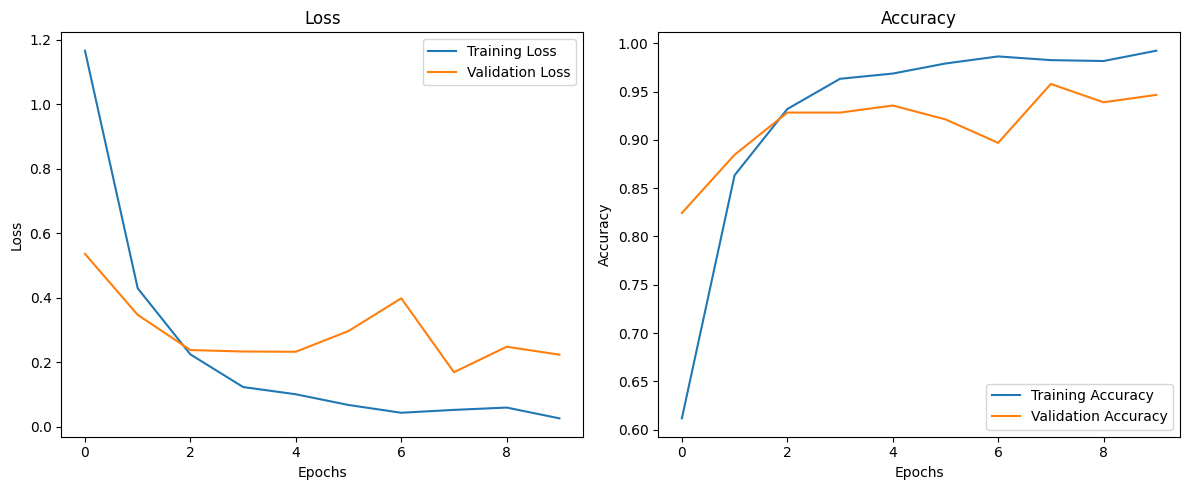

In [13]:
import matplotlib.pyplot as plt

# Accessing the history data
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# If you have accuracy metrics
train_accuracy = history.history.get('accuracy', None)
val_accuracy = history.history.get('val_accuracy', None)


# Plotting loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot (if applicable)
if train_accuracy is not None and val_accuracy is not None:
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracy, label='Training Accuracy')
    plt.plot(val_accuracy, label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()


In [15]:
image_gen = ImageDataGenerator(rescale=1./255)
test_data = image_gen.flow_from_directory(
    '/kaggle/input/vegetable-image-dataset/Vegetable Images/test',
    target_size=(128,128),
    seed=42,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32
)

Found 3000 images belonging to 15 classes.


In [16]:
result = model.evaluate(test_data)

94/94 ━━━━━━━━━━━━━━━━━━━━ 27s 289ms/step - accuracy: 0.9346 - loss: 0.2724
